# Atoti DataMart & OLAP - Crypto Data Warehouse
**Team 4 INT24 | Data Warehouse Final Project 2025/2026**

This notebook builds a DataMart using **Atoti** from the data loaded into Supabase.

### 6 Analytical Targets:
1. Volatility profile per asset & time period
2. Sentiment vs price movement correlation
3. Trend distribution across time hierarchy
4. Volume anomaly & price impact
5. RSI momentum & trend reversal patterns
6. Market anomaly vs price impact (ML-based)


We add more analytical target after we implement modeling because why not? Nevertheless, it is interesting

In [36]:
import subprocess
subprocess.run(['pip', 'install', 'pyarrow', 'python-dotenv'], check=True)

CompletedProcess(args=['pip', 'install', 'pyarrow', 'python-dotenv'], returncode=0)

In [37]:

import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path('../.env'))

SUPABASE_URL = os.getenv('SUPABASE_URL')
SUPABASE_KEY = os.getenv('SUPABASE_KEY')
PROCESSED    = Path('../data/processed')

print('Environment loaded')
print(f'   SUPABASE_URL = {SUPABASE_URL[:40]}...' if SUPABASE_URL else '   SUPABASE_URL not found')

Environment loaded
   SUPABASE_URL = https://zynmpfvpgrfyqgofuylb.supabase.co...


In [38]:

def load_from_supabase(table: str) -> pd.DataFrame:
    """Load table dari Supabase via REST API."""
    import requests
    headers = {
        'apikey': SUPABASE_KEY,
        'Authorization': f'Bearer {SUPABASE_KEY}',
    }
    all_rows = []
    limit = 1000
    offset = 0
    while True:
        url = f'{SUPABASE_URL}/rest/v1/{table}?select=*&limit={limit}&offset={offset}'
        resp = requests.get(url, headers=headers, timeout=30)
        resp.raise_for_status()
        rows = resp.json()
        all_rows.extend(rows)
        if len(rows) < limit:
            break
        offset += limit
    print(f'   Loaded {table}: {len(all_rows):,} rows')
    return pd.DataFrame(all_rows)

def load_latest_parquet(prefix: str) -> pd.DataFrame:
    files = sorted(PROCESSED.glob(f'{prefix}_*.parquet'))
    if not files:
        files = sorted(PROCESSED.glob(f'{prefix}_*.csv'))
        return pd.read_csv(files[-1])
    return pd.read_parquet(files[-1])

print('Loading data...')
try:
    fact_daily   = load_from_supabase('fact_market_daily')
    fact_hourly  = load_from_supabase('fact_market_hourly')
    dim_time     = load_from_supabase('dim_time')
    dim_asset    = load_from_supabase('dim_asset')
    dim_sentiment= load_from_supabase('dim_sentiment')
    dim_trend    = load_from_supabase('dim_trend')
    source = 'Supabase'
except Exception as e:
    print(f' Supabase connection failed ({e}), falling back to local Parquet...')
    fact_daily   = load_latest_parquet('fact_market_daily')
    fact_hourly  = load_latest_parquet('fact_market_hourly')
    dim_time     = load_latest_parquet('dim_time')
    dim_asset    = load_latest_parquet('dim_asset')
    dim_sentiment= load_latest_parquet('dim_sentiment')
    dim_trend    = load_latest_parquet('dim_trend')
    source = 'lokal (parquet)'

print(f'\n Data loaded from: {source}')
print(f'   fact_market_daily : {len(fact_daily):,} rows')

Loading data...
   Loaded fact_market_daily: 3,650 rows
   Loaded fact_market_hourly: 464,062 rows
   Loaded dim_time: 738 rows
   Loaded dim_asset: 5 rows
   Loaded dim_sentiment: 5 rows
   Loaded dim_trend: 9 rows

 Data loaded from: Supabase
   fact_market_daily : 3,650 rows


In [39]:

df = fact_daily.copy()

df = df.merge(dim_time[['date_key','date','year','quarter','month','week','day_of_week','day_name','is_weekend']],
              on='date_key', how='left')
df = df.merge(dim_asset[['asset_key','symbol','name','category']], on='asset_key', how='left')
df = df.merge(dim_sentiment[['sentiment_key','fng_classification','fng_label']], on='sentiment_key', how='left')
df = df.merge(dim_trend[['trend_key','trend_label','rsi_signal']], on='trend_key', how='left')

df['date']         = pd.to_datetime(df['date'])
df['year']         = df['year'].astype(str)
df['quarter']      = 'Q' + df['quarter'].astype(str)
df['month']        = df['month'].astype(int)
df['week']         = df['week'].astype(int)

numeric_cols = ['open','high','low','close','volume','fng_value',
                'daily_return','ma7','ma30','volatility_7d','rsi_14','volume_zscore']

if 'is_market_anomaly_ml' in df.columns:
    df['is_market_anomaly_ml'] = df['is_market_anomaly_ml'].astype(str) 
if 'predicted_fng_label_tomorrow' in df.columns:
    df['predicted_fng_label_tomorrow'] = df['predicted_fng_label_tomorrow'].astype(str)
    
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f' Denormalized DataFrame shape: {df.shape}')
print(f'   Columns: {list(df.columns)}')
df.head(3)

 Denormalized DataFrame shape: (3650, 35)
   Columns: ['fact_key', 'date_key', 'asset_key', 'sentiment_key', 'trend_key', 'open', 'high', 'low', 'close', 'volume', 'fng_value', 'daily_return', 'ma7', 'ma30', 'volatility_7d', 'rsi_14', 'volume_zscore', 'is_volume_anomaly', 'is_market_anomaly_ml', 'predicted_fng_label_tomorrow', 'date', 'year', 'quarter', 'month', 'week', 'day_of_week', 'day_name', 'is_weekend', 'symbol', 'name', 'category', 'fng_classification', 'fng_label', 'trend_label', 'rsi_signal']


,fact_key,date_key,asset_key,sentiment_key,trend_key,open,high,low,close,volume,...,day_of_week,day_name,is_weekend,symbol,name,category,fng_classification,fng_label,trend_label,rsi_signal
0,1474,20240615,1,4.0,3,66006.742188,66402.187500,65871.773438,66191.000000,1.715999e+08,...,5,Saturday,True,BTC-USD,Bitcoin,Cryptocurrency,greed,Greed,bearish,oversold
1,1521,20240801,1,3.0,4,64630.863281,65519.277344,62271.566406,65353.500000,1.198486e+10,...,3,Thursday,False,BTC-USD,Bitcoin,Cryptocurrency,neutral,Neutral,bullish,neutral
2,1522,20240802,1,4.0,4,65306.316406,65486.585938,61195.230469,61414.808594,7.858700e+09,...,4,Friday,False,BTC-USD,Bitcoin,Cryptocurrency,greed,Greed,bullish,neutral


In [40]:
import atoti as tt

session = tt.Session.start()
print(f' Atoti session started: {session.url}')

 Atoti session started: http://localhost:55451


In [41]:

store = session.read_pandas(
    df,
    table_name='crypto_market',
    keys=['fact_key']
)

cube = session.create_cube(store, name='Crypto DWH Cube')

print('  Cube created')
print('   Available Measures:', list(cube.measures.keys())[:10], '...')
print('   Available Hierarchies:', list(cube.hierarchies.keys()))

  Cube created
   Available Measures: ['asset_key.MEAN', 'asset_key.SUM', 'close.MEAN', 'close.SUM', 'contributors.COUNT', 'daily_return.MEAN', 'daily_return.SUM', 'date_key.MEAN', 'date_key.SUM', 'day_of_week.MEAN'] ...
   Available Hierarchies: [('crypto_market', 'is_weekend'), ('crypto_market', 'fng_label'), ('crypto_market', 'is_market_anomaly_ml'), ('crypto_market', 'fact_key'), ('crypto_market', 'rsi_signal'), ('crypto_market', 'predicted_fng_label_tomorrow'), ('crypto_market', 'fng_classification'), ('crypto_market', 'date'), ('crypto_market', 'trend_label'), ('crypto_market', 'symbol'), ('crypto_market', 'category'), ('crypto_market', 'is_volume_anomaly'), ('crypto_market', 'day_name'), ('crypto_market', 'name'), ('crypto_market', 'quarter'), ('crypto_market', 'year')]


In [45]:
m, h = cube.measures, cube.hierarchies

m['Avg Close']         = tt.agg.mean(store['close'])
m['Avg Daily Return']  = tt.agg.mean(store['daily_return'])
m['Avg Volatility 7d'] = tt.agg.mean(store['volatility_7d'])
m['Avg RSI 14']        = tt.agg.mean(store['rsi_14'])
m['Total Volume']      = tt.agg.sum(store['volume'])
m['Avg FnG Score']     = tt.agg.mean(store['fng_value'])
m['Max Daily Return']  = tt.agg.max(store['daily_return'])
m['Min Daily Return']  = tt.agg.min(store['daily_return'])
m['Volatility Max']    = tt.agg.max(store['volatility_7d'])

print('Custom measures created')


Custom measures created


In [46]:

print('=== ML: Market Anomaly vs Price & Volatility ===')
result_ml = cube.query(
    m['Avg Daily Return'],
    m['Avg Volatility 7d'],
    m['Avg Close'],
    m['contributors.COUNT'],
    levels=[
        h['is_market_anomaly_ml']['is_market_anomaly_ml'],
        h['symbol']['symbol']
    ]
)
result_ml

=== ML: Market Anomaly vs Price & Volatility ===


Avg Daily Return Avg Volatility 7d  Avg Close  \
is_market_anomaly_ml symbol                                                  
False                ADA-USD             -.00               .04        .56   
                     BNB-USD              .00               .02     700.62   
                     BTC-USD              .00               .02  87,567.81   
                     ETH-USD             -.00               .03   2,918.89   
                     SOL-USD             -.00               .04     153.35   
True                 ADA-USD              .06               .14        .70   
                     BNB-USD              .12               .06   1,116.94   
                     BTC-USD             -.11               .04  58,347.90   
                     ETH-USD              .04               .07   2,805.36   
                     SOL-USD              .04               .09     185.13   

                             contributors.COUNT  
is_market_anomaly_ml symbol                      
False                ADA-USD                708  
                     BNB-USD                726  
                     BTC-USD                727  
                     ETH-USD                721  
                     SOL-USD                731  
True                 ADA-USD                 17  
                     BNB-USD                  3  
                     BTC-USD                  2  
                     ETH-USD                  8  
                     SOL-USD                  7

## Analytical Target 1 - Volatility Profile per Asset & Time

In [47]:
print('=== T1: Avg Volatility 7d - per Quarter per Asset ===')
result_t1 = cube.query(
    m['Avg Volatility 7d'],
    m['Avg Daily Return'],
    levels=[h['symbol']['symbol'], h['quarter']['quarter']]
)
result_t1

=== T1: Avg Volatility 7d - per Quarter per Asset ===


Avg Volatility 7d Avg Daily Return
symbol  quarter                                   
ADA-USD Q1                    .05             -.00
        Q2                    .03             -.00
        Q3                    .03              .00
        Q4                    .05              .00
BNB-USD Q1                    .03             -.00
        Q2                    .02              .00
        Q3                    .02              .00
        Q4                    .03              .00
BTC-USD Q1                    .03             -.00
        Q2                    .02              .00
        Q3                    .02              .00
        Q4                    .02              .00
ETH-USD Q1                    .04             -.00
        Q2                    .03              .00
        Q3                    .03              .00
        Q4                    .03              .00
SOL-USD Q1                    .04             -.00
        Q2                    .03              .00
        Q3                    .04              .00
        Q4                    .04             -.00

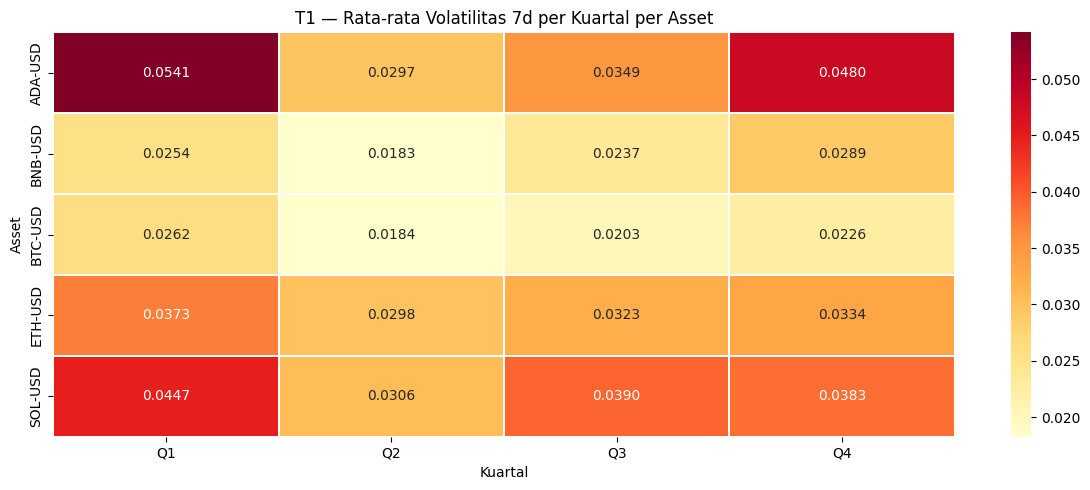

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

vol_pivot = result_t1['Avg Volatility 7d'].unstack('symbol')
vol_pivot = vol_pivot.astype(float)  

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(vol_pivot.T, cmap='YlOrRd', annot=True, fmt='.4f', linewidths=0.3, ax=ax)
ax.set_title('T1 — Rata-rata Volatilitas 7d per Kuartal per Asset')
ax.set_xlabel('Kuartal')
ax.set_ylabel('Asset')
plt.tight_layout()
plt.show()

## Analytical Target 2 - Sentiment vs Price Movement

In [49]:
print('=== T2: Avg Daily Return per Sentiment Label per Asset ===')
result_t2 = cube.query(
    m['Avg Daily Return'],
    m['Avg FnG Score'],
    m['Avg Volatility 7d'],
    levels=[h['fng_label']['fng_label'], h['symbol']['symbol']]
)
result_t2

=== T2: Avg Daily Return per Sentiment Label per Asset ===


Avg Daily Return Avg FnG Score Avg Volatility 7d
fng_label     symbol                                                  
Extreme Fear  ADA-USD              .00         15.87               .05
              BNB-USD              .00         15.80               .03
              BTC-USD              .00         15.80               .03
              ETH-USD              .00         15.80               .04
              SOL-USD              .00         15.87               .04
Extreme Greed ADA-USD              .01         79.41               .06
              BNB-USD             -.00         79.41               .03
              BTC-USD              .00         79.41               .03
              ETH-USD             -.00         79.41               .04
              SOL-USD             -.00         79.41               .04
Fear          ADA-USD             -.00         35.64               .04
              BNB-USD              .00         35.60               .02
              BTC-USD             -.00         35.60               .02
              ETH-USD             -.00         35.60               .03
              SOL-USD             -.00         35.35               .04
Greed         ADA-USD             -.00         67.97               .03
              BNB-USD              .00         67.97               .02
              BTC-USD              .00         67.97               .02
              ETH-USD              .00         67.97               .03
              SOL-USD              .00         67.97               .03
N/A           ADA-USD              .03                             .04
              BNB-USD              .01                             .02
              BTC-USD              .01                             .02
              ETH-USD              .02                             .03
              SOL-USD              .04                             .04
Neutral       ADA-USD              .00         51.60               .03
              BNB-USD              .00         51.60               .02
              BTC-USD              .00         51.60               .02
              ETH-USD              .00         51.60               .03
              SOL-USD             -.00         51.60               .03

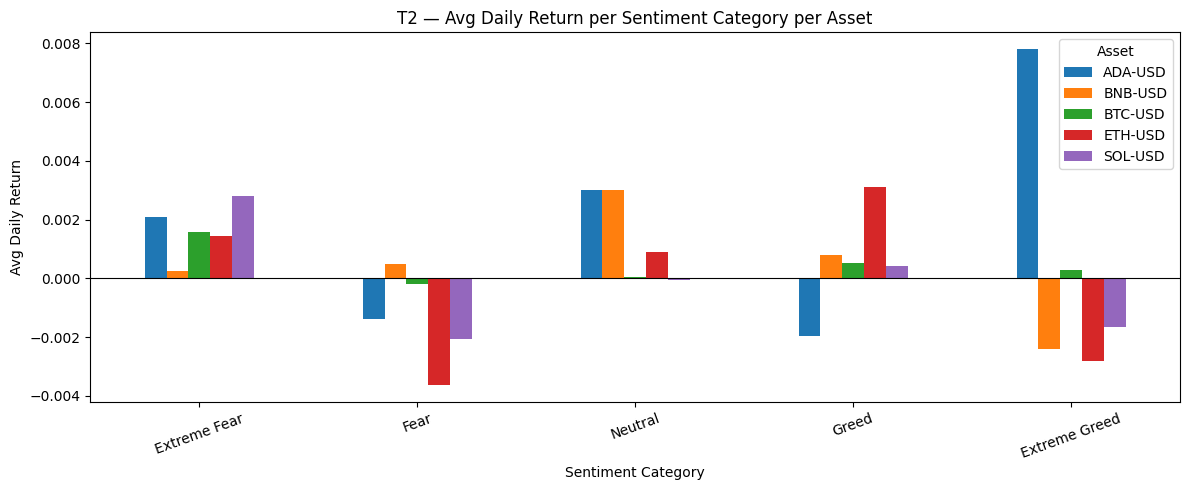

In [50]:
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

try:
    ret_pivot = result_t2['Avg Daily Return'].unstack('symbol')
    ret_pivot = ret_pivot.reindex([s for s in sentiment_order if s in ret_pivot.index])

    fig, ax = plt.subplots(figsize=(12, 5))
    ret_pivot.plot(kind='bar', ax=ax)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('T2 — Avg Daily Return per Sentiment Category per Asset')
    ax.set_xlabel('Sentiment Category')
    ax.set_ylabel('Avg Daily Return')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
    ax.legend(title='Asset')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Visualisasi error: {e} — cek struktur index result_t2')

##  Analytical Target 3 - Trend Distribution Across Time

In [51]:
print('=== T3: Trend Distribution per Quarter per Asset ===')
result_t3 = cube.query(
    m['contributors.COUNT'],
    levels=[
        h['symbol']['symbol'],
        h['trend_label']['trend_label'],
        h['year']['year'],
        h['quarter']['quarter']
    ]
)
result_t3.head(20)

=== T3: Trend Distribution per Quarter per Asset ===


contributors.COUNT
symbol  trend_label year quarter                    
ADA-USD bearish     2024 Q2                       26
                         Q3                       55
                         Q4                       45
                    2025 Q1                       63
                         Q2                       55
                         Q3                       37
                         Q4                       88
                    2026 Q1                       66
                         Q2                       32
        bullish     2024 Q2                        2
                         Q3                       37
                         Q4                       47
                    2025 Q1                       27
                         Q2                       36
                         Q3                       55
                    2026 Q1                       24
                         Q2                       23
        neutral     2024 Q2                        7
BNB-USD bearish     2024 Q2                       18
                         Q3                       47

In [52]:
result_t3_btc = cube.query(
    m['contributors.COUNT'],
    levels=[h['trend_label']['trend_label'], h['year']['year'], h['quarter']['quarter']],
    filter=h['symbol']['symbol'] == 'BTC-USD'
)
result_t3_btc

contributors.COUNT
trend_label year quarter                   
bearish     2024 Q2                      20
                 Q3                      52
                 Q4                      15
            2025 Q1                      64
                 Q2                      34
                 Q3                      37
                 Q4                      76
            2026 Q1                      48
                 Q2                      16
bullish     2024 Q2                       8
                 Q3                      40
                 Q4                      77
            2025 Q1                      26
                 Q2                      57
                 Q3                      55
                 Q4                      16
            2026 Q1                      42
                 Q2                      39
neutral     2024 Q2                       7

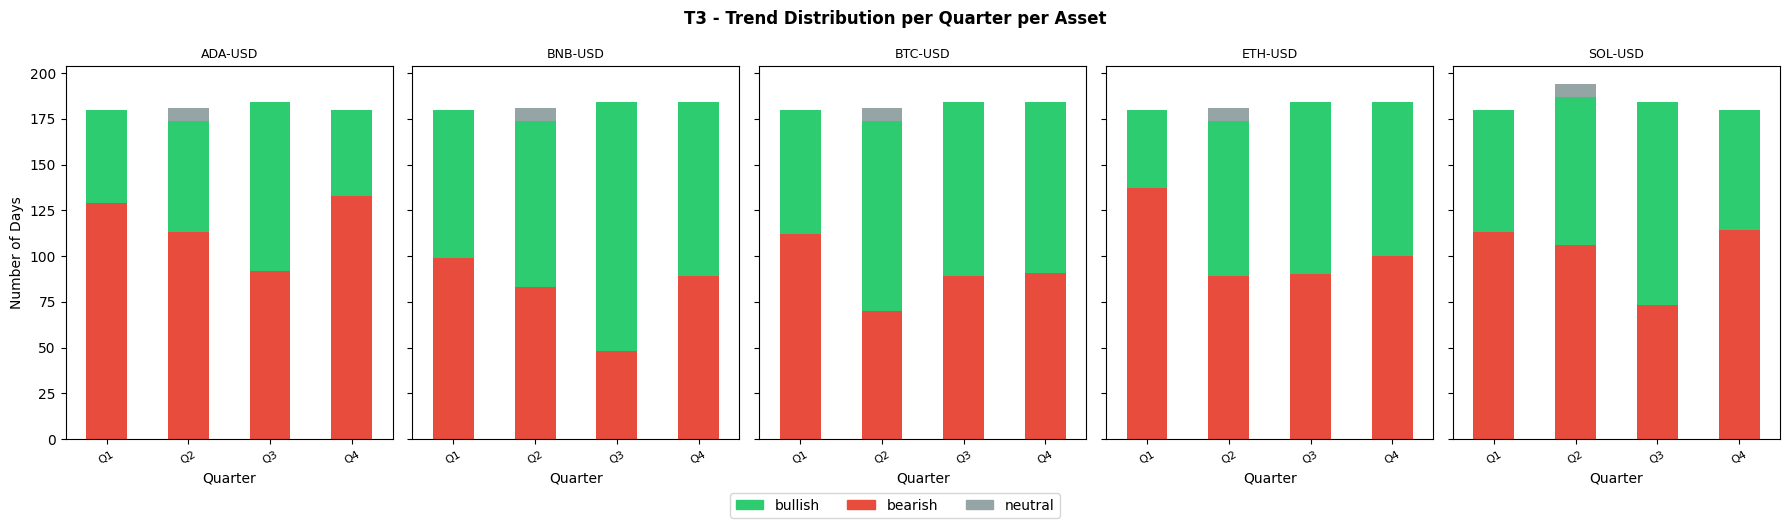

In [53]:
result_t3_q = cube.query(
    m['contributors.COUNT'],
    levels=[h['symbol']['symbol'], h['trend_label']['trend_label'], h['quarter']['quarter']]
)

try:
    df_t3 = result_t3_q.reset_index()
    pivot = df_t3.pivot_table(index=['symbol','quarter'], columns='trend_label',
                              values='contributors.COUNT', fill_value=0)

    fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True)
    symbols = df_t3['symbol'].unique()
    colors = {'bullish': '#2ecc71', 'bearish': '#e74c3c', 'neutral': '#95a5a6'}

    for ax, sym in zip(axes, symbols):
        sub = pivot.loc[sym] if sym in pivot.index.get_level_values(0) else pd.DataFrame()
        if len(sub) > 0:
            sub.plot(kind='bar', stacked=True, ax=ax,
                     color=[colors.get(c,'gray') for c in sub.columns])
        ax.set_title(sym, fontsize=9)
        ax.set_xlabel('Quarter')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, fontsize=8)
        ax.get_legend().remove() if ax.get_legend() else None

    axes[0].set_ylabel('Number of Days')
    fig.suptitle('T3 - Trend Distribution per Quarter per Asset', fontsize=12, fontweight='bold')
    handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors.values()]
    fig.legend(handles, colors.keys(), loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Visualisasi error: {e}')

##  Analytical Target 4 - Volume Anomaly & Price Impact

In [54]:
print('=== T4: Volume & Return per Sentiment per Asset ===')
result_t4 = cube.query(
    m['Total Volume'],
    m['Avg Daily Return'],
    m['contributors.COUNT'],
    levels=[h['symbol']['symbol'], h['fng_label']['fng_label']]
)
result_t4

=== T4: Volume & Return per Sentiment per Asset ===


Total Volume Avg Daily Return  \
symbol  fng_label                                              
ADA-USD Extreme Fear      28,636,727,120.00              .00   
        Extreme Greed     55,087,064,800.00              .01   
        Fear              91,763,254,672.00             -.00   
        Greed             53,716,994,240.00             -.00   
        N/A                   48,779,104.00              .03   
        Neutral           13,894,044,384.00              .00   
BNB-USD Extreme Fear      64,238,579,776.00              .00   
        Extreme Greed     30,549,218,816.00             -.00   
        Fear              91,856,713,536.00              .00   
        Greed             73,532,701,952.00              .00   
        N/A                   71,738,112.00              .01   
        Neutral           21,636,099,200.00              .00   
BTC-USD Extreme Fear   2,017,006,029,824.00              .00   
        Extreme Greed  1,103,822,405,632.00              .00   
        Fear           2,845,846,137,856.00             -.00   
        Greed          2,822,779,696,128.00              .00   
        N/A                1,675,874,304.00              .01   
        Neutral          636,711,502,848.00              .00   
ETH-USD Extreme Fear   1,143,679,252,480.00              .00   
        Extreme Greed    594,833,050,112.00             -.00   
        Fear           1,705,352,615,424.00             -.00   
        Greed          1,921,252,434,944.00              .00   
        N/A                1,645,645,824.00              .02   
        Neutral          489,332,544,512.00              .00   
SOL-USD Extreme Fear     190,014,733,312.00              .00   
        Extreme Greed    135,846,761,344.00             -.00   
        Fear             293,729,452,672.00             -.00   
        Greed            260,556,688,640.00              .00   
        N/A                  354,360,320.00              .04   
        Neutral           78,829,550,080.00             -.00   

                      contributors.COUNT  
symbol  fng_label                         
ADA-USD Extreme Fear                 141  
        Extreme Greed                 66  
        Fear                         244  
        Greed                        216  
        N/A                            1  
        Neutral                       57  
BNB-USD Extreme Fear                 144  
        Extreme Greed                 66  
        Fear                         245  
        Greed                        216  
        N/A                            1  
        Neutral                       57  
BTC-USD Extreme Fear                 144  
        Extreme Greed                 66  
        Fear                         245  
        Greed                        216  
        N/A                            1  
        Neutral                       57  
ETH-USD Extreme Fear                 144  
        Extreme Greed                 66  
        Fear                         245  
        Greed                        216  
        N/A                            1  
        Neutral                       57  
SOL-USD Extreme Fear                 141  
        Extreme Greed                 66  
        Fear                         257  
        Greed                        216  
        N/A                            1  
        Neutral                       57

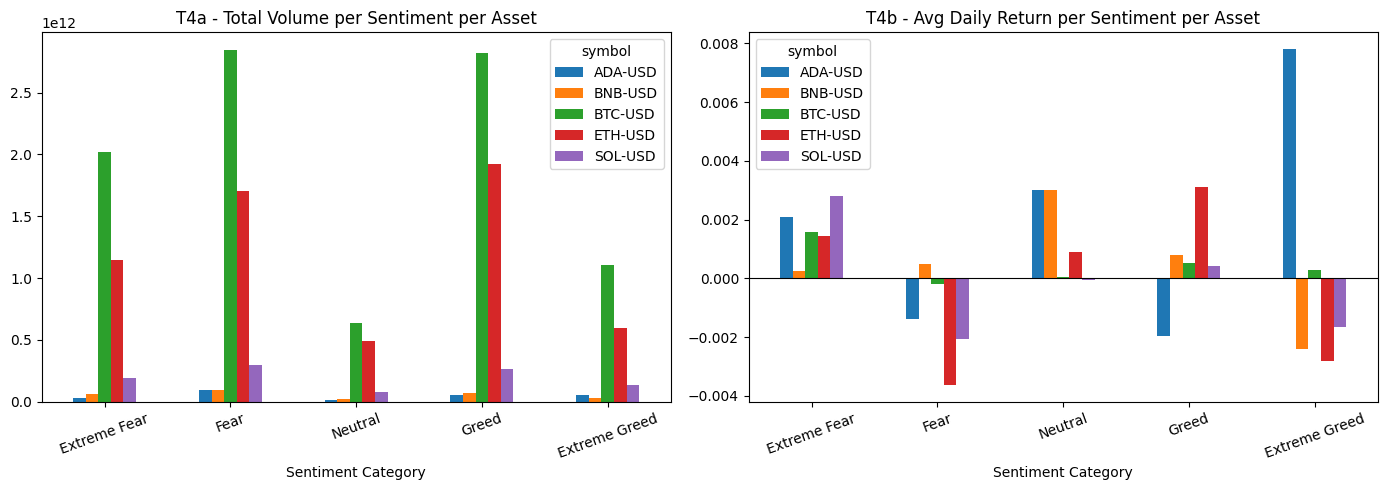

In [55]:
try:
    df_t4 = result_t4.reset_index()
    sentiment_order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    vol_pivot = df_t4.pivot_table(index='fng_label', columns='symbol',
                                   values='Total Volume', aggfunc='sum')
    vol_pivot = vol_pivot.reindex([s for s in sentiment_order if s in vol_pivot.index])
    vol_pivot.plot(kind='bar', ax=axes[0])
    axes[0].set_title('T4a - Total Volume per Sentiment per Asset')
    axes[0].set_xlabel('Sentiment Category')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)

    ret_pivot = df_t4.pivot_table(index='fng_label', columns='symbol',
                                   values='Avg Daily Return', aggfunc='mean')
    ret_pivot = ret_pivot.reindex([s for s in sentiment_order if s in ret_pivot.index])
    ret_pivot.plot(kind='bar', ax=axes[1])
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title('T4b - Avg Daily Return per Sentiment per Asset')
    axes[1].set_xlabel('Sentiment Category')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Visualisasi error: {e}')

## Analytical Target 5 - RSI Momentum & Trend Reversal

In [56]:
print('=== T5: RSI Signal Distribution per Trend per Asset ===')
result_t5 = cube.query(
    m['contributors.COUNT'],
    m['Avg RSI 14'],
    m['Avg Daily Return'],
    levels=[h['symbol']['symbol'], h['rsi_signal']['rsi_signal'], h['trend_label']['trend_label']]
)
result_t5

=== T5: RSI Signal Distribution per Trend per Asset ===


contributors.COUNT Avg RSI 14 Avg Daily Return
symbol  rsi_signal trend_label                                               
ADA-USD neutral    bearish                    428      43.21              .00
                   bullish                    207      53.48             -.01
                   neutral                      7                        -.01
        overbought bearish                      1      73.20              .72
                   bullish                     44      78.64              .04
        oversold   bearish                     38      24.49             -.04
BNB-USD neutral    bearish                    291      44.68              .00
                   bullish                    369      55.29             -.00
                   neutral                      7                        -.00
        overbought bullish                     34      76.15              .03
        oversold   bearish                     28      26.34             -.03
BTC-USD neutral    bearish                    325      44.48              .00
                   bullish                    317      57.35             -.00
                   neutral                      7                        -.00
        overbought bullish                     40      74.94              .02
        oversold   bearish                     37      24.75             -.02
                   bullish                      3      25.22             -.01
ETH-USD neutral    bearish                    379      42.11              .00
                   bullish                    260      55.89             -.00
                   neutral                      7                        -.00
        overbought bullish                     46      76.85              .03
        oversold   bearish                     37      25.43             -.03
SOL-USD neutral    bearish                    375      43.07              .00
                   bullish                    294      55.73             -.00
                   neutral                      7                        -.01
        overbought bullish                     31      73.84              .04
        oversold   bearish                     31      26.96             -.03

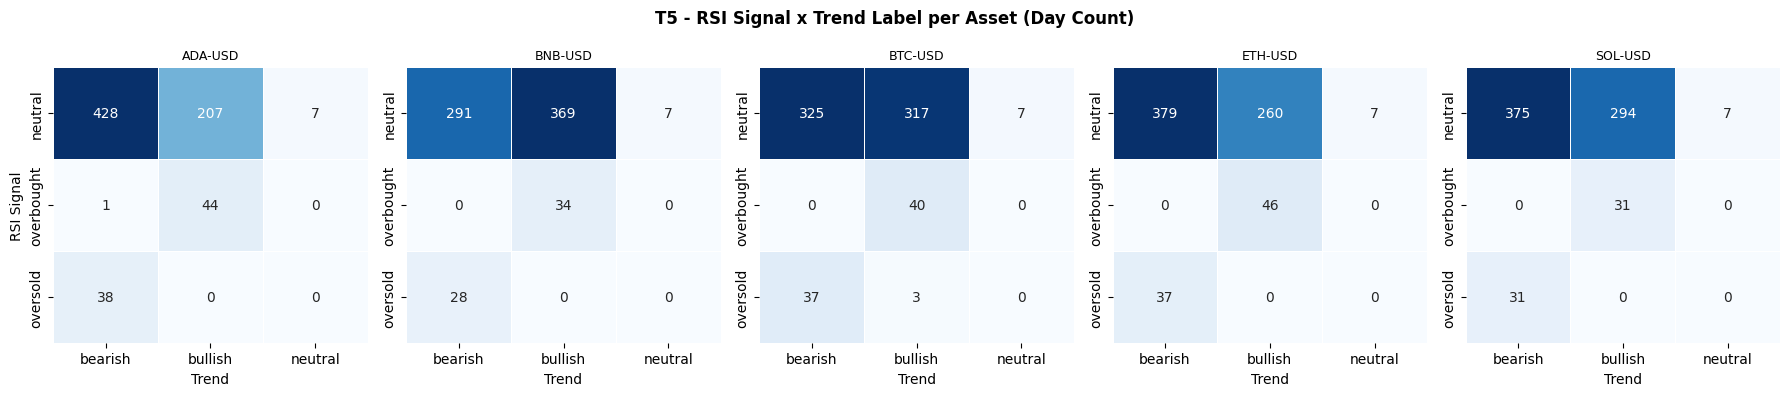

In [57]:
try:
    df_t5 = result_t5.reset_index()
    df_t5['contributors.COUNT'] = pd.to_numeric(df_t5['contributors.COUNT'], errors='coerce')
    
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    symbols = sorted(df_t5['symbol'].unique())
    
    for ax, sym in zip(axes, symbols):
        sub = df_t5[df_t5['symbol'] == sym]
        pivot = sub.pivot_table(index='rsi_signal', columns='trend_label',
                                values='contributors.COUNT', fill_value=0, aggfunc='sum')
        pivot = pivot.astype(float)  
        sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues', ax=ax,
                    cbar=False, linewidths=0.5)
        ax.set_title(sym, fontsize=9)
        ax.set_xlabel('Trend')
        ax.set_ylabel('RSI Signal' if sym == symbols[0] else '')
    
    fig.suptitle('T5 - RSI Signal x Trend Label per Asset (Day Count)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Visualisasi error: {e}')

## Analytical Target 6 — Market Anomaly vs Price Impact (ML)

In [58]:

print('=== ML: Market Anomaly vs Price & Volatility ===')
result_ml = cube.query(
    m['Avg Daily Return'],
    m['Avg Volatility 7d'],
    m['Avg Close'],
    m['contributors.COUNT'],
    levels=[
        h['is_market_anomaly_ml']['is_market_anomaly_ml'],
        h['symbol']['symbol']
    ]
)
result_ml

=== ML: Market Anomaly vs Price & Volatility ===


Avg Daily Return Avg Volatility 7d  Avg Close  \
is_market_anomaly_ml symbol                                                  
False                ADA-USD             -.00               .04        .56   
                     BNB-USD              .00               .02     700.62   
                     BTC-USD              .00               .02  87,567.81   
                     ETH-USD             -.00               .03   2,918.89   
                     SOL-USD             -.00               .04     153.35   
True                 ADA-USD              .06               .14        .70   
                     BNB-USD              .12               .06   1,116.94   
                     BTC-USD             -.11               .04  58,347.90   
                     ETH-USD              .04               .07   2,805.36   
                     SOL-USD              .04               .09     185.13   

                             contributors.COUNT  
is_market_anomaly_ml symbol                      
False                ADA-USD                708  
                     BNB-USD                726  
                     BTC-USD                727  
                     ETH-USD                721  
                     SOL-USD                731  
True                 ADA-USD                 17  
                     BNB-USD                  3  
                     BTC-USD                  2  
                     ETH-USD                  8  
                     SOL-USD                  7

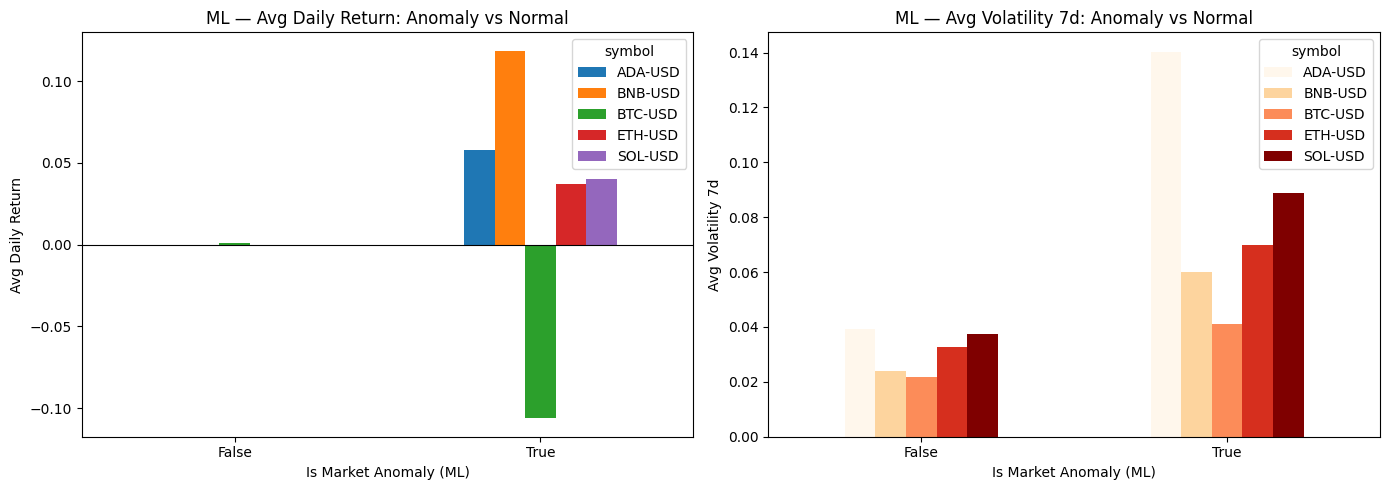

In [59]:
# Chart: Market Anomaly vs Price
try:
    df_ml = result_ml.reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Avg Daily Return per anomaly flag per asset
    ret_pivot = df_ml.pivot_table(
        index='is_market_anomaly_ml', columns='symbol',
        values='Avg Daily Return', aggfunc='mean'
    )
    ret_pivot.plot(kind='bar', ax=axes[0])
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_title('ML — Avg Daily Return: Anomaly vs Normal')
    axes[0].set_xlabel('Is Market Anomaly (ML)')
    axes[0].set_ylabel('Avg Daily Return')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

    # Right: Avg Volatility per anomaly flag per asset
    vol_pivot = df_ml.pivot_table(
        index='is_market_anomaly_ml', columns='symbol',
        values='Avg Volatility 7d', aggfunc='mean'
    )
    vol_pivot.plot(kind='bar', ax=axes[1], colormap='OrRd')
    axes[1].set_title('ML — Avg Volatility 7d: Anomaly vs Normal')
    axes[1].set_xlabel('Is Market Anomaly (ML)')
    axes[1].set_ylabel('Avg Volatility 7d')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Visualisasi error: {e}')

##  Atoti Widget (Interactive Dashboard)

In [60]:
widget_t1 = cube.query(
    m['Avg Volatility 7d'],
    m['Avg Daily Return'],
    m['Avg RSI 14'],
    levels=[h['symbol']['symbol'], h['year']['year'], h['quarter']['quarter']]
)
print('=== Widget 1: Volatility Profile per Year-Quarter per Asset ===')
widget_t1

=== Widget 1: Volatility Profile per Year-Quarter per Asset ===


Avg Volatility 7d Avg Daily Return Avg RSI 14
symbol  year quarter                                              
ADA-USD 2024 Q2                    .02             -.00      23.57
             Q3                    .03              .00      47.67
             Q4                    .05              .01      58.59
        2025 Q1                    .07              .00      45.82
             Q2                    .04             -.00      46.64
             Q3                    .04              .00      55.41
             Q4                    .05             -.01      37.92
        2026 Q1                    .04             -.00      43.57
             Q2                    .02              .00      49.24
BNB-USD 2024 Q2                    .02             -.00      39.83
             Q3                    .03              .00      49.24
             Q4                    .03              .00      55.23
        2025 Q1                    .03             -.00      46.85
             Q2                    .02              .00      52.27
             Q3                    .02              .00      63.65
             Q4                    .03             -.00      46.51
        2026 Q1                    .02             -.00      43.79
             Q2                    .02              .00      52.01
BTC-USD 2024 Q2                    .01             -.00      24.68
             Q3                    .03              .00      48.85
             Q4                    .02              .00      61.83
        2025 Q1                    .03             -.00      46.92
             Q2                    .02              .00      57.93
             Q3                    .01              .00      53.62
             Q4                    .02             -.00      43.27
        2026 Q1                    .03             -.00      44.60
             Q2                    .02              .00      56.85
ETH-USD 2024 Q2                    .02             -.00      28.94
             Q3                    .03             -.00      42.89
             Q4                    .03              .00      55.91
        2025 Q1                    .04             -.01      40.48
             Q2                    .04              .00      53.90
             Q3                    .03              .01      61.04
             Q4                    .03             -.00      43.32
        2026 Q1                    .04             -.00      44.53
             Q2                    .02              .00      51.23
SOL-USD 2024 Q2                    .03             -.00      32.45
             Q3                    .04              .00      49.99
             Q4                    .04              .00      55.97
        2025 Q1                    .05             -.00      44.57
             Q2                    .04              .00      51.86
             Q3                    .04              .00      56.82
             Q4                    .04             -.01      41.02
        2026 Q1                    .04             -.00      44.38
             Q2                    .02             -.00      49.54

In [61]:
widget_t2 = cube.query(
    m['Avg Daily Return'],
    m['Avg Volatility 7d'],
    m['Avg FnG Score'],
    levels=[
        h['fng_label']['fng_label'],
        h['symbol']['symbol'],
        h['trend_label']['trend_label']
    ]
)
print('=== Widget T2: Sentiment x Asset x Trend ===')
widget_t2

=== Widget T2: Sentiment x Asset x Trend ===


Avg Daily Return Avg Volatility 7d  \
fng_label     symbol  trend_label                                      
Extreme Fear  ADA-USD bearish                  .00               .04   
                      bullish                  .01               .10   
              BNB-USD bearish                 -.00               .03   
                      bullish                  .00               .02   
              BTC-USD bearish                  .00               .03   
                      bullish                  .00               .02   
              ETH-USD bearish                  .00               .04   
                      bullish                  .00               .03   
              SOL-USD bearish                  .00               .04   
                      bullish                  .00               .03   
Extreme Greed ADA-USD bearish                 -.02               .03   
                      bullish                  .01               .06   
              BNB-USD bearish                  .00               .02   
                      bullish                 -.00               .03   
              BTC-USD bearish                 -.02               .02   
                      bullish                  .00               .03   
              ETH-USD bearish                 -.01               .03   
                      bullish                 -.00               .04   
              SOL-USD bearish                 -.02               .04   
                      bullish                  .00               .05   
Fear          ADA-USD bearish                  .00               .04   
                      bullish                 -.01               .05   
              BNB-USD bearish                  .00               .03   
                      bullish                 -.00               .02   
              BTC-USD bearish                  .00               .02   
                      bullish                 -.00               .02   
              ETH-USD bearish                 -.00               .03   
                      bullish                 -.00               .03   
              SOL-USD bearish                 -.00               .04   
                      bullish                 -.00               .03   
Greed         ADA-USD bearish                 -.01               .03   
                      bullish                  .00               .04   
                      neutral                 -.01               .01   
              BNB-USD bearish                 -.00               .02   
                      bullish                  .00               .02   
                      neutral                 -.00               .01   
              BTC-USD bearish                  .00               .02   
                      bullish                  .00               .02   
                      neutral                 -.00               .01   
              ETH-USD bearish                 -.00               .03   
                      bullish                  .01               .03   
                      neutral                 -.00               .01   
              SOL-USD bearish                 -.00               .04   
                      bullish                  .00               .03   
                      neutral                 -.01               .00   
N/A           ADA-USD bearish                  .03               .04   
              BNB-USD bullish                  .01               .02   
              BTC-USD bullish                  .01               .02   
              ETH-USD bullish                  .02               .03   
              SOL-USD bullish                  .04               .04   
Neutral       ADA-USD bearish                  .00               .03   
                      bullish                  .00               .03   
              BNB-USD bearish                 -.00               .02   
                      bullish                  .01               .02   
  

In [62]:
widget_t3 = cube.query(
    m['contributors.COUNT'],
    m['Avg Daily Return'],
    levels=[
        h['symbol']['symbol'],
        h['trend_label']['trend_label'],
        h['quarter']['quarter'],
        h['year']['year']
    ]
)
print('=== Widget T3: Trend Distribution per Quarter per Asset ===')
widget_t3

=== Widget T3: Trend Distribution per Quarter per Asset ===


contributors.COUNT Avg Daily Return
symbol  trend_label quarter year                                    
ADA-USD bearish     Q1      2025                 63              .00
                            2026                 66              .00
                    Q2      2024                 26             -.00
                            2025                 55             -.00
                            2026                 32              .00
...                                             ...              ...
SOL-USD bullish     Q3      2024                 35             -.00
                            2025                 76              .00
                    Q4      2024                 62              .01
                            2025                  4             -.01
        neutral     Q2      2024                  7             -.01

[91 rows x 2 columns]

In [63]:
widget_t4 = cube.query(
    m['Total Volume'],
    m['Avg Daily Return'],
    m['contributors.COUNT'],
    levels=[
        h['symbol']['symbol'],
        h['fng_label']['fng_label'],
        h['quarter']['quarter']
    ]
)
print('=== Widget T4: Volume Anomaly x Sentiment x Quarter ===')
widget_t4

=== Widget T4: Volume Anomaly x Sentiment x Quarter ===


Total Volume Avg Daily Return  \
symbol  fng_label     quarter                                       
ADA-USD Extreme Fear  Q1       14,150,006,480.00              .00   
                      Q2        4,317,710,272.00              .01   
                      Q3          129,113,792.00              .04   
                      Q4       10,039,896,576.00             -.00   
        Extreme Greed Q1        5,591,364,544.00             -.02   
...                                          ...              ...   
SOL-USD N/A           Q4          354,360,320.00              .04   
        Neutral       Q1        4,159,904,640.00             -.02   
                      Q2        8,771,902,336.00              .00   
                      Q3       55,264,361,408.00              .01   
                      Q4       10,633,381,696.00             -.01   

                              contributors.COUNT  
symbol  fng_label     quarter                     
ADA-USD Extreme Fear  Q1                      72  
                      Q2                      20  
                      Q3                       4  
                      Q4                      45  
        Extreme Greed Q1                      13  
...                                          ...  
SOL-USD N/A           Q4                       1  
        Neutral       Q1                       8  
                      Q2                      10  
                      Q3                      32  
                      Q4                       7  

[105 rows x 3 columns]

In [64]:
widget_t5 = cube.query(
    m['Avg RSI 14'],
    m['Avg Daily Return'],
    m['contributors.COUNT'],
    levels=[
        h['symbol']['symbol'],
        h['rsi_signal']['rsi_signal'],
        h['trend_label']['trend_label'],
        h['quarter']['quarter']
    ]
)
print('=== Widget T5: RSI Signal x Trend x Quarter ===')
widget_t5

=== Widget T5: RSI Signal x Trend x Quarter ===


Avg RSI 14 Avg Daily Return  \
symbol  rsi_signal trend_label quarter                               
ADA-USD neutral    bearish     Q1           43.39              .00   
                               Q2           42.60              .00   
                               Q3           45.87              .01   
                               Q4           41.55             -.00   
                   bullish     Q1           50.24             -.01   
...                                           ...              ...   
SOL-USD overbought bullish     Q3           73.58              .04   
                               Q4           74.06              .02   
        oversold   bearish     Q1           26.67             -.04   
                               Q2           26.74             -.02   
                               Q4           28.71             -.04   

                                       contributors.COUNT  
symbol  rsi_signal trend_label quarter                     
ADA-USD neutral    bearish     Q1                     119  
                               Q2                      94  
                               Q3                      90  
                               Q4                     125  
                   bullish     Q1                      51  
...                                                   ...  
SOL-USD overbought bullish     Q3                       8  
                               Q4                      14  
        oversold   bearish     Q1                      16  
                               Q2                      11  
                               Q4                       4  

[81 rows x 3 columns]

In [65]:
widget_t6 = cube.query(
    m['Avg Daily Return'],
    m['Avg Volatility 7d'],
    m['Avg Close'],
    m['contributors.COUNT'],
    levels=[
        h['is_market_anomaly_ml']['is_market_anomaly_ml'],
        h['symbol']['symbol'],
        h['quarter']['quarter']
    ]
)
print('=== Widget T6: Market Anomaly vs Price Impact ===')
widget_t6

=== Widget T6: Market Anomaly vs Price Impact ===


Avg Daily Return Avg Volatility 7d  \
is_market_anomaly_ml symbol  quarter                                      
False                ADA-USD Q1                  -.00               .05   
                             Q2                  -.00               .03   
                             Q3                   .00               .03   
                             Q4                  -.00               .05   
                     BNB-USD Q1                  -.00               .03   
                             Q2                   .00               .02   
                             Q3                   .00               .02   
                             Q4                  -.00               .03   
                     BTC-USD Q1                  -.00               .03   
                             Q2                   .00               .02   
                             Q3                   .00               .02   
                             Q4                   .00               .02   
                     ETH-USD Q1                  -.00               .04   
                             Q2                  -.00               .03   
                             Q3                   .00               .03   
                             Q4                   .00               .03   
                     SOL-USD Q1                  -.01               .04   
                             Q2                   .00               .03   
                             Q3                   .00               .04   
                             Q4                  -.00               .04   
True                 ADA-USD Q1                   .06               .24   
                             Q2                  -.02               .01   
                             Q3                  -.09               .04   
                             Q4                   .09               .09   
                     BNB-USD Q4                   .12               .06   
                     BTC-USD Q1                  -.14               .05   
                             Q3                  -.07               .03   
                     ETH-USD Q1                  -.01               .07   
                             Q2                   .13               .08   
                             Q3                   .02               .05   
                             Q4                  -.12               .05   
                     SOL-USD Q1                   .06               .10   
                             Q4                  -.01               .06   

                                      Avg Close contributors.COUNT  
is_market_anomaly_ml symbol  quarter                                
False                ADA-USD Q1             .56                173  
                             Q2             .50                180  
                             Q3             .59                183  
                             Q4             .61                172  
                     BNB-USD Q1          685.13                180  
                             Q2          626.49                181  
                             Q3          688.52                184  
                             Q4          802.47                181  
                     BTC-USD Q1       85,069.64                179  
                             Q2       85,548.41                181  
                             Q3       87,937.80                183  
                             Q4       91,616.57                184  
                     ETH-USD Q1        2,543.58                178  
                             Q2        2,482.89                178  
                             Q3        3,363.52                182  
                             Q4        3,265.86                183  
                     SOL-USD Q1          139.40                175  
                             Q2          127.49                194  
                             Q3

In [66]:
print('=' * 60)
print('OLAP SUMMARY - CRYPTO DATA WAREHOUSE')
print('=' * 60)
print(f'\n Total Rows in Cube : {len(df):,}')
print(f' Number of Measures     : {len(list(cube.measures.keys()))}')
print(f'  Number of Hierarchies  : {len(list(cube.hierarchies.keys()))}')
print('\n 5 Analytical Targets:')
print('   T1:  Volatility Profile per Asset & Time (Roll-up: daily→quarterly)')
print('   T2:  Sentiment vs Price Movement (Drill-down: label→score + Slice per asset)')
print('   T3:  Trend Distribution (Dice: trend×asset + Roll-up ke monthly/quarterly)')
print('   T4:  Volume Anomaly & Price Impact (Slice: time + Dice: asset×sentiment)')
print('   T5:  RSI Momentum & Trend Reversal (Drill-down: trend×asset per period)')
print('   T6:  Market Anomaly vs Price Impact (Slice: ML anomaly flag × asset × return)')
print('\n OLAP Completed.')

OLAP SUMMARY - CRYPTO DATA WAREHOUSE

 Total Rows in Cube : 3,650
 Number of Measures     : 49
  Number of Hierarchies  : 16

 5 Analytical Targets:
   T1:  Volatility Profile per Asset & Time (Roll-up: daily→quarterly)
   T2:  Sentiment vs Price Movement (Drill-down: label→score + Slice per asset)
   T3:  Trend Distribution (Dice: trend×asset + Roll-up ke monthly/quarterly)
   T4:  Volume Anomaly & Price Impact (Slice: time + Dice: asset×sentiment)
   T5:  RSI Momentum & Trend Reversal (Drill-down: trend×asset per period)
   T6:  Market Anomaly vs Price Impact (Slice: ML anomaly flag × asset × return)

 OLAP Completed.


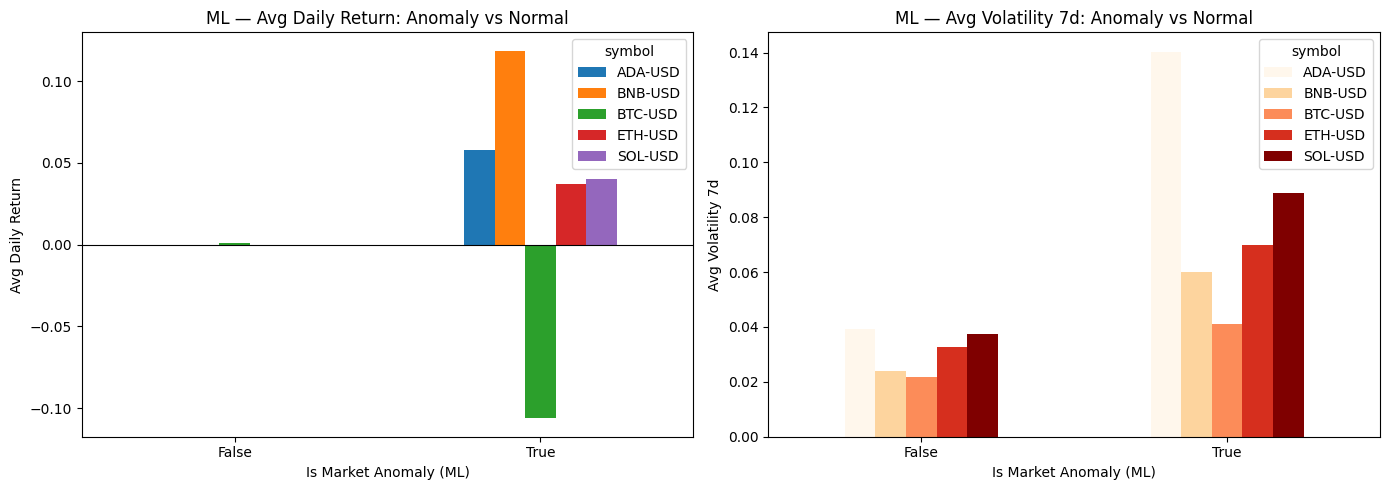

In [67]:
# Chart: Market Anomaly vs Price
try:
    df_ml = result_ml.reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Avg Daily Return per anomaly flag per asset
    ret_pivot = df_ml.pivot_table(
        index='is_market_anomaly_ml', columns='symbol',
        values='Avg Daily Return', aggfunc='mean'
    )
    ret_pivot.plot(kind='bar', ax=axes[0])
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_title('ML — Avg Daily Return: Anomaly vs Normal')
    axes[0].set_xlabel('Is Market Anomaly (ML)')
    axes[0].set_ylabel('Avg Daily Return')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

    # Right: Avg Volatility per anomaly flag per asset
    vol_pivot = df_ml.pivot_table(
        index='is_market_anomaly_ml', columns='symbol',
        values='Avg Volatility 7d', aggfunc='mean'
    )
    vol_pivot.plot(kind='bar', ax=axes[1], colormap='OrRd')
    axes[1].set_title('ML — Avg Volatility 7d: Anomaly vs Normal')
    axes[1].set_xlabel('Is Market Anomaly (ML)')
    axes[1].set_ylabel('Avg Volatility 7d')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Visualisasi error: {e}')